# Chapter 5: Simple Neural Architecture

In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

In [2]:
np.random.seed(42)

x_train = np.linspace(-10, 10, num=500)
y_train = 3 * x_train + 7 + np.random.normal(0, 10, size=x_train.shape)

x_train_reshaped = np.array([np.array([x]) for x in x_train])
y_train_reshaped = np.where(y_train > 0, 1, 0)

In [3]:
class Differentiable_Perceptron:
    """
    A simple perceptron model with differentiable activation function.
    Technically, a true perceptron uses a heaviside step function as its activation function.
    However, people often use a differentiable activation function such as ReLU or sigmoid
    since they introduce non-linearity to the model and can be trained using backpropagation.
    Technically, this no longer is a perceptron, but it is a simple neural network.
    A true perceptron can only output 0 or 1, whereas a differentiable activation function can  output any real number.
    """
    def __init__(self, input_dim, learning_rate=0.1,
        activation_function=lambda x: x):
        self.weights = np.zeros(input_dim + 1)
        self.learning_rate = learning_rate
        self.activation_function = activation_function

    def predict(self, inputs):
        summation = np.dot(inputs, self.weights[1:]) + self.weights[0]
        return self.activation_function(summation)

    def train(self, training_inputs, labels, epochs=20):
        for _ in range(epochs):
            for inputs, label in zip(training_inputs, labels):
                summation = np.dot(inputs, self.weights[1:]) + self.weights[0]
                prediction = self.activation_function(summation)
                error = label - prediction
                self.weights[1:] += self.learning_rate * error * inputs
                self.weights[0] += self.learning_rate * error

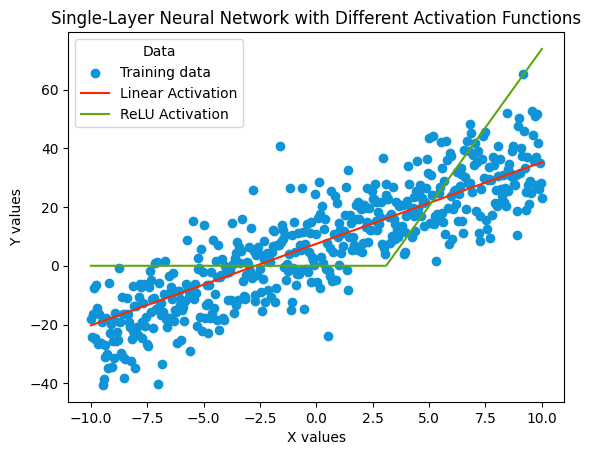

In [4]:
# set seed
np.random.seed(42)

# Instantiate Perceptron class with linear activation
nn_linear = Differentiable_Perceptron(1, activation_function=lambda x: x, learning_rate=
0.001)

# Train Perceptron
nn_linear.train(x_train_reshaped, y_train, epochs=200)

# Some activation functions to test
relu = lambda x: np.maximum(0, x)
sigmoid = lambda x: 1 / (1 + np.exp(-x))
tanh = lambda x: np.tanh(x)

# Instantiate Perceptron class with ReLU activation
nn_relu = Differentiable_Perceptron(1, activation_function=relu, learning_rate= 0.00001)

# Train Perceptron
nn_relu.train(x_train_reshaped, y_train, epochs=1000)

# Scatterplot of training data
plt.scatter(x_train, y_train, color='#0F95D7', label='Training data')

# Lineplot of predictions for linear activation
y_pred_linear = [nn_linear.predict(np.array([x])) for x in x_train]
plt.plot(x_train, y_pred_linear, color='#FF2700', label='Linear Activation')

# Lineplot of predictions for ReLU activation
y_pred_relu = [nn_relu.predict(np.array([x])) for x in x_train]
plt.plot(x_train, y_pred_relu, color='#5FA613', label='ReLU Activation')
plt.xlabel('X values')
plt.ylabel('Y values')
plt.title('Single-Layer Neural Network with Different Activation Functions')
plt.legend(title='Data', loc='best')
plt.show()

Not bad! The ReLU activation isn’t as good as the simple linear activation, simply because the data is
a linear construct with noise. Regardless, both do a much better job than the unit step activation of
the true perceptron. Now what happens if we up the complexity of the data? Let us attempt to model
the Airline Passengers data.

To build a model of time series data with our neuron we need some features to help capture the
sequential nature of the data, so we create 1:12 lag vectors of the dependent (passenger numbers),
which we can interpret as the number of passengers from the previous month to year. We do this with
a minmax data transformation, and use 200 epochs.

We apply the following process:
1. We load the dataset, convert the date column to datetime, and set it as the index for time
series handling:

In [5]:
import pandas as pd
import Utilities.PathUtilities as Path

# Set seed
np.random.seed(42)

# Load dataset
data = pd.read_csv(Path.get_current_working_directory().parent / 'Data' / 'passengers.csv')

# Preprocess data
# Convert 'date' to datetime
data['date'] = pd.to_datetime(data['date'])
# Set 'date' as the index
data.set_index('date', inplace=True)

data.head()

,passengers
date,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121


2. We split the dataset into training (60%), validation (20%), and test (20%) sets. This is done
chronologically to preserve temporal structure.

In [6]:
# Sequential split
train_size = int(len(data) * 0.6)
val_size = int(len(data) * 0.2)

train, val, test = data[:train_size], data[train_size:train_size + val_size], data[train_size + val_size:]

3. We apply Min-Max scaling. The scaler is fit only on the training data and applied to the rest.

In [7]:
from sklearn.preprocessing import MinMaxScaler

# Scaling: Min-max
scaler = MinMaxScaler()
train_scaled = scaler.fit_transform(train)
val_scaled = scaler.transform(val)
test_scaled = scaler.transform(test)

4. We convert the time series into supervised learning format using 12 lagged observations to
capture yearly seasonality:

In [8]:
# Prepare data with lags
def prepare_data(data, max_lag=12):
    dataX, dataY = [], []
    for i in range(max_lag, len(data) - 1):
        dataX.append(data[i - max_lag:i, 0])
        dataY.append(data[i, 0])
    return np.array(dataX), np.array(dataY)

lags = 12
trainX, trainY = prepare_data(train_scaled, lags)
valX, valY = prepare_data(val_scaled, lags)
testX, testY = prepare_data(test_scaled, lags)

5. We define the ReLU activation function to introduce nonlinearity:

In [9]:
# Initialize model with ReLU activation function
def relu(x):
    return np.maximum(0, x)

6. We create a differentiable perceptron using the specified input size, learning rate, and activation function:

In [10]:
diff_perceptron = Differentiable_Perceptron(input_dim=lags, learning_rate=0.001, activation_function=relu)

7.  We train the model iteratively and monitor validation loss. Training stops if no improvement
is seen for 10 consecutive epochs:

In [11]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error

# Early stopping parameters
best_val_loss = float('inf')
patience, wait = 10, 0
# Train model with early stopping
for epoch in range(200):
    diff_perceptron.train(trainX, trainY, epochs=1)
    val_predictions = diff_perceptron.predict(valX)
    val_loss = mean_squared_error(valY, val_predictions)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        wait = 0
    else:
        wait += 1

    if wait >= patience:
        print(f"Early stopping on epoch {epoch}")
        break

8. We generate predictions for the training, validation, and test sets:

In [12]:
# Generate test predictions
scaled_predictions = diff_perceptron.predict(testX)

# In-sample predictions
train_predictions = diff_perceptron.predict(trainX)

unscaled_train_predictions = scaler.inverse_transform(train_predictions.
reshape(-1, 1))
train_pred_index = data.index[
 lags:lags + len(unscaled_train_predictions)]

# Validation predictions
val_predictions_plot = diff_perceptron.predict(valX)
unscaled_val_predictions = scaler.inverse_transform(val_predictions_plot.reshape(-1, 1))
val_pred_index = data.index[train_size + lags:train_size + lags + len(unscaled_val_predictions)]

9. We convert predictions back to the original scale for interpretation:

In [13]:
# Inverse Scaling
unscaled_predictions = scaler.inverse_transform(scaled_predictions.reshape(-1, 1))
test_index = data.index[-len(unscaled_predictions):]

In [14]:
import Utilities.ErrorMetricsUtilities as err
target = scaler.inverse_transform(testY.reshape(-1, 1))
(mae, rmse, mape) = err.calculate_metrics(target, unscaled_predictions)

print("MAE:", mae)
print("RMSE:", rmse)
print("MAPE:", mape)

MAE: 41.1347477509641
RMSE: 55.37249556515367
MAPE: 0.0827848157258614


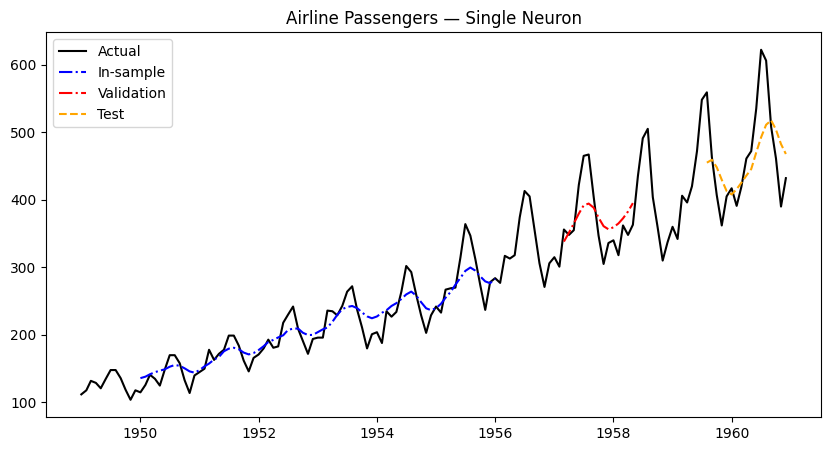

In [15]:
from Utilities.ColorUtilities import custom_palette

# --- Single neuron predictions plot ---
plt.figure(figsize=(10,5))
plt.plot(data.index, data['passengers'], label='Actual', color=custom_palette[0])
plt.plot(train_pred_index, unscaled_train_predictions,
         label='In-sample', color=custom_palette[1], linestyle='-.')
plt.plot(val_pred_index, unscaled_val_predictions,
         label='Validation', color=custom_palette[3], linestyle='-.')
plt.plot(test_index, unscaled_predictions,
         label='Test', color=custom_palette[2], linestyle='--')
plt.title('Airline Passengers — Single Neuron')
plt.legend()
plt.show()

### Building a neural network

It’s time to bring everything we’ve covered together, and more. Our previous models were simple
perceptrons and neurons, for which we did not fully control the training process. In training a neural
network we add some complexities, like backpropagation.

In [16]:
import torch
from torch import nn
from torch.optim import Adam
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

In [26]:
def create_time_windows(data, window_size):
    inputs = []
    targets = []
    for i in range(len(data) - window_size):
        inputs.append(data[i:i+window_size])
        targets.append(data[i+window_size])
    return np.array(inputs), np.array(targets)

window_size = 12 # good parameter to play with to understand effect
train_inputs, train_targets = create_time_windows(train_scaled, window_size)
val_inputs, val_targets = create_time_windows(val_scaled, window_size)
test_inputs, test_targets = create_time_windows(test_scaled, window_size)

We then take these and convert them into simple one-dimensional tensors for the FFN. This will
convert them from 3D arrays to 1D tensors, with the following dimensions:
- Batch size/sample number. Each sample is a time window of lagged values.
- Window size, length of each time window (n = 12).
- Feature dimension, as we have only one feature (passengers), this dimension is 1.

In PyTorch nomenclature, this gives us a [BatchSize, SequenceLength, FeatureDimension] tensor,
a typical format for sequential data. We can verify this by calling .shape on the tensor objects.

In [27]:
# Convert numpy arrays to PyTorch tensors
x_train = torch.FloatTensor(train_inputs)
y_train = torch.FloatTensor(train_targets)
x_val = torch.FloatTensor(val_inputs)
y_val = torch.FloatTensor(val_targets)
x_test = torch.FloatTensor(test_inputs)
y_test = torch.FloatTensor(test_targets)

# Print shapes
x_train.shape, y_train.shape, x_val.shape, y_val.shape, x_test.shape, y_test.shape
(torch.Size([74, 12, 1]),
 torch.Size([74, 1]),
 torch.Size([16, 12, 1]),
 torch.Size([16, 1]),
 torch.Size([18, 12, 1]),
 torch.Size([18, 1]))

(torch.Size([74, 12, 1]),
 torch.Size([74, 1]),
 torch.Size([16, 12, 1]),
 torch.Size([16, 1]),
 torch.Size([18, 12, 1]),
 torch.Size([18, 1]))

In [28]:
# Define FFN model
class ff_network(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim=1):
        super(ff_network, self).__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        out = self.fc1(x)
        out = self.relu(out)
        out = self.fc2(out)
        return out

In [29]:
np.random.seed(42)

# Initialize FFN
input_dim = 12
hidden_dim = 100 # Tunable
output_dim = 1 # We are predicting a single output
model = ff_network(input_dim, hidden_dim, output_dim)

# Loss and optimizer
criterion = nn.MSELoss()
optimizer = Adam(model.parameters(), lr=0.0001)

# Early stopping parameters
best_val_loss = float('inf')
patience, wait = 10, 0

# Lists to hold loss values for plotting
train_losses = []
val_losses = []

# Best model checkpoint
best_model_state = None

# Training loop with early stopping
for epoch in range(2000):
    model.train()
    optimizer.zero_grad()

    # Flatten time window dimension
    outputs = model(x_train.view(-1, window_size))
    loss = criterion(outputs, y_train)
    loss.backward()
    optimizer.step()

    # Store train loss
    train_losses.append(loss.item())
    model.eval()
    with torch.no_grad():
        val_outputs = model(x_val.view(-1, window_size))
        val_loss = criterion(val_outputs, y_val)

    # Store validation loss
    val_losses.append(val_loss.item())

    if val_loss.item() < best_val_loss:
        best_val_loss = val_loss.item()
        wait = 10

        # Save best model's state
        best_model_state = model.state_dict()
    else:
        wait += 1
        if wait >= patience:
            print(f"Early stopping on epoch {epoch}")
            break

# Load best model's state
if best_model_state:
    model.load_state_dict(best_model_state)

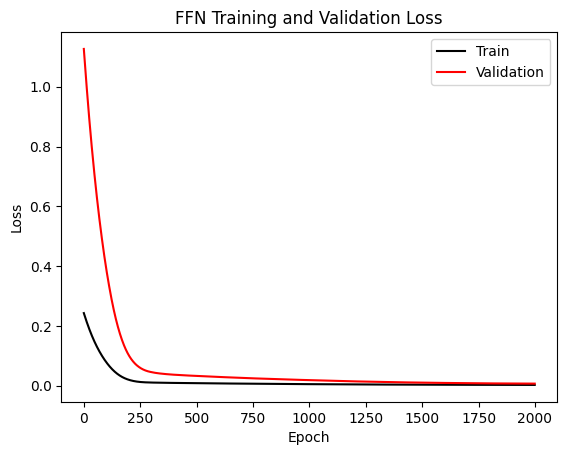

In [30]:
# --- Training and validation loss ---
plt.plot(range(epoch + 1), train_losses, label='Train', color=custom_palette[0])
plt.plot(range(epoch + 1), val_losses, label='Validation', color=custom_palette[3])
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('FFN Training and Validation Loss')
plt.legend()
plt.show()

In [31]:
model.eval()
with torch.no_grad():
    train_preds = model(x_train.view(-1, window_size)).numpy()
    val_preds = model(x_val.view(-1, window_size)).numpy()
    test_preds = model(x_test.view(-1, window_size)).numpy()

train_preds = scaler.inverse_transform(train_preds)
val_preds = scaler.inverse_transform(val_preds)
test_preds = scaler.inverse_transform(test_preds)
all_actuals = scaler.inverse_transform(np.concatenate([y_train, y_val, y_test]).reshape(-1, 1))

all_preds = np.concatenate([train_preds, val_preds, test_preds])
pred_index = data.index[window_size:window_size + len(all_preds)]

insample_end = len(train_preds) + len(val_preds)

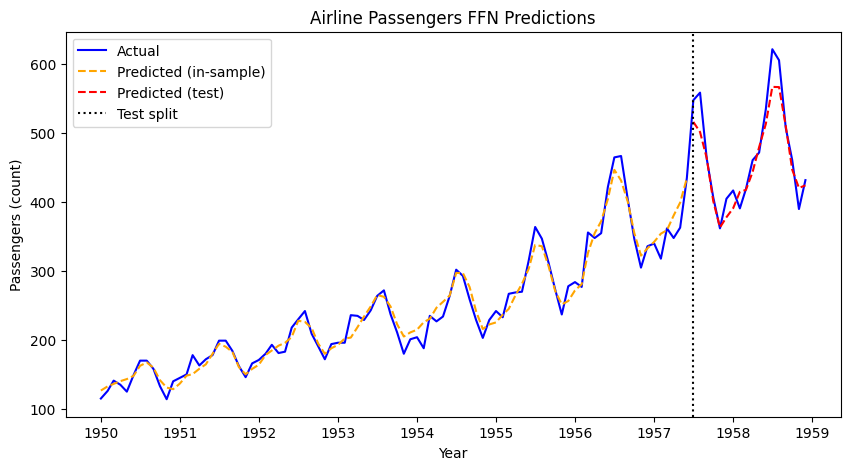

In [33]:
plt.figure(figsize=(10, 5))
plt.plot(pred_index, all_actuals, label='Actual', color=custom_palette[1])
plt.plot(pred_index[:insample_end], all_preds[:insample_end],
         label='Predicted (in-sample)', color=custom_palette[2], linestyle='--')
plt.plot(pred_index[insample_end:], all_preds[insample_end:],
         label='Predicted (test)', color=custom_palette[3], linestyle='--')
plt.axvline(pred_index[insample_end], color=custom_palette[0],
            linestyle=':', label='Test split')
plt.xlabel('Year')
plt.ylabel('Passengers (count)')
plt.title('Airline Passengers FFN Predictions')
plt.legend()
plt.show()

In [34]:
import Utilities.ErrorMetricsUtilities as err
unscaled_actuals = scaler.inverse_transform(y_test.detach().numpy().reshape(-1, 1))

ffn_err_df = pd.DataFrame({
    'MAE': [err.mae(unscaled_actuals, test_preds)],
    'MSE': [err.mse(unscaled_actuals, test_preds)],
    'RMSE': [err.rmse(unscaled_actuals, test_preds)],
    'MAPE': [err.mape(unscaled_actuals, test_preds)],
    'sMAPE': [err.smape(unscaled_actuals, test_preds)]
}, index=['FFN'])
print(ffn_err_df.to_string())

           MAE        MSE       RMSE      MAPE     sMAPE
FFN  20.489468  709.66626  26.639563  4.157142  4.239867
